In [94]:
import numpy as np
import scipy.constants as sc
import matplotlib.pyplot as plt
import pandas as pd

In [95]:
nfft = 32
pad = 3
bins = np.arange(1, nfft//2)
n = nfft + pad
df = pd.read_csv('./xschem/simulation/th_nmos.txt', sep='\\s+')
df

,time,v(vop)
0,1.250000e-07,0.311920
1,2.250000e-07,0.330632
2,3.250000e-07,0.347892
3,4.250000e-07,0.363030
4,5.250000e-07,0.375464
...,...,...
520,3.125000e-06,0.274344
521,3.225000e-06,0.291260
522,3.325000e-06,0.313347
523,3.425000e-06,0.253349


In [96]:
t = df['time']
t = t[0:n]
v = np.reshape(df['v(vop)'].values, [len(df)//n, n])

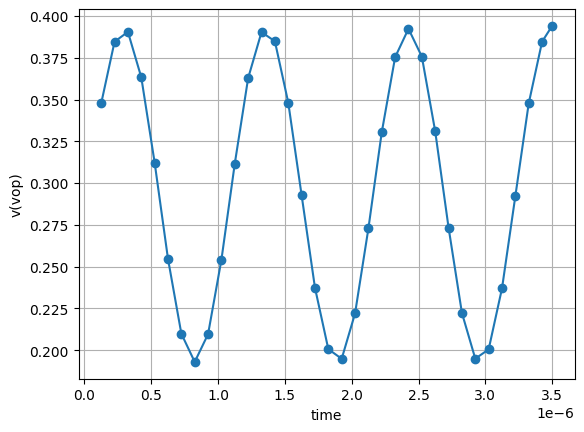

In [97]:
y = v[bin-1, :]
plt.plot(t, y, "-o")
plt.grid()
plt.ylabel("v(vop)")
plt.xlabel("time")
plt.show()

In [98]:
# Check periodicity/steady state by comparing the last valid sample of the FFT window with one right before the window
# Remove last point since it's off the sampling grid
y = y[:-1]
print(len(y))
relative_error = (y[-1]-y[-1-nfft])/y[-1]
print(relative_error)
y = y[-nfft:]
print(len(y))

34
-2.5999035839197917e-09
32


In [99]:
spec = np.fft.rfft(y)
spec_dbv = 20*np.log10(np.abs(spec)/(nfft))
sfdr = spec_dbv[bin] - np.max(np.delete(spec_dbv, [0, bin]))
print(spec_dbv)
print("SFDR: ", sfdr, "dB")    

[ -10.67385613 -141.24922221 -142.52859843  -26.04887583 -135.41352754
 -137.65832372  -89.19929085 -140.6103579  -135.19419868 -117.72049455
 -137.56204878 -145.44989461 -133.39969193 -133.98629283 -151.85637497
 -140.43401635 -146.58117439]
SFDR:  63.15041501076084 dB


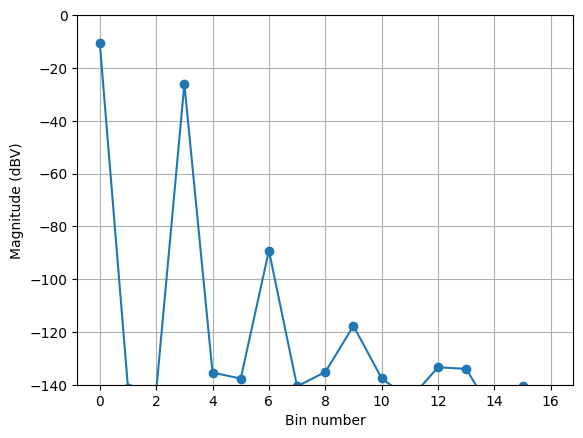

In [100]:
plt.plot(spec_dbv, "-o")
plt.grid()
plt.xlabel("Bin number")
plt.ylabel("Magnitude (dBV)")
plt.ylim([-140, 0])
plt.show()

In [101]:
sfdr = np.zeros(len(bins))
for i in bins:
    y = v[i-1, :]
    y = y[:-1]
    y = y[-nfft:]
    spec = np.fft.rfft(y)
    spec_dbv = 20*np.log10(np.abs(spec)/(nfft))
    sfdr[i-1] = spec_dbv[i] - np.max(np.delete(spec_dbv, [0, i]))
    print("Bin: ", i, "SFDR: ", sfdr[i-1]   , "dB")

Bin:  1 SFDR:  64.11496567314643 dB
Bin:  2 SFDR:  63.759920979312085 dB
Bin:  3 SFDR:  63.15041501076084 dB
Bin:  4 SFDR:  62.46684271737777 dB
Bin:  5 SFDR:  61.738099317753644 dB
Bin:  6 SFDR:  61.02595039718975 dB
Bin:  7 SFDR:  60.24560624448712 dB
Bin:  8 SFDR:  58.361458648087634 dB
Bin:  9 SFDR:  58.82367221217015 dB
Bin:  10 SFDR:  58.15054352861032 dB
Bin:  11 SFDR:  57.520299454737945 dB
Bin:  12 SFDR:  56.90505582451693 dB
Bin:  13 SFDR:  56.341699193354074 dB
Bin:  14 SFDR:  55.81008529646835 dB
Bin:  15 SFDR:  55.2895008309127 dB


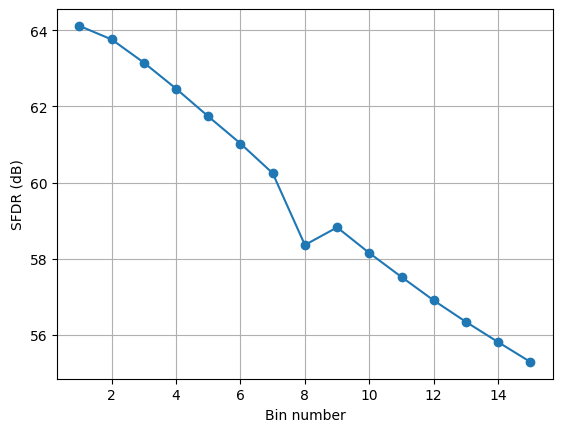

In [102]:
plt.plot(bins, sfdr, "-o")
plt.grid()
plt.xlabel("Bin number")
plt.ylabel("SFDR (dB)")
plt.show()